<a href="https://colab.research.google.com/github/pr0fez/AI24-Programmering/blob/master/Exercises/E10-numpy.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

# Numpy exercises

---
These are introductory exercises in Python with focus in **Numpy**.

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable names</b> in order to get readable code </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to format your answers in a neat way using <b>f-strings</b>

<p class = "alert alert-info" role="alert"><b>Remember</b> to format your input questions in a pedagogical way to guide the user

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 1. Dice simulations (*)

Simulations of one die,  

&nbsp; a) Calculate theoretical mean of a dice (six-sided) (*)

&nbsp; b) Now do simulations of

- 10
- 100
- 1000
- 10000
- 100000
- 1000000
- 10000000

number of dices and plot their means. (*)

<details>

<summary>Answer </summary>

a)
```
3.5
```

b) 

<img src="../assets/numpy_1b.png" width = 300>

</details>




In [1]:
# A
import numpy as np

print(f"The theoretical mean of a dice is {np.mean(range(1,7))}.")

The theoretical mean of a dice is 3.5.


The mean of 10 throws is 3.7.
The mean of 100 throws is 3.43.
The mean of 1000 throws is 3.335.
The mean of 10000 throws is 3.4944.
The mean of 100000 throws is 3.48885.
The mean of 1000000 throws is 3.498495.
The mean of 10000000 throws is 3.5008217.


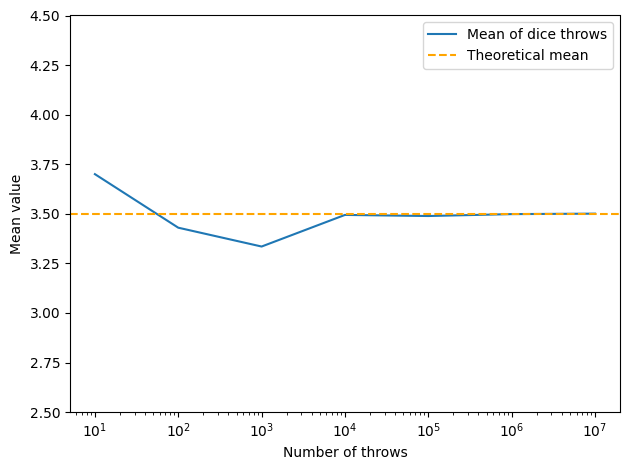

In [11]:
# B
import matplotlib.pyplot as plt
dice_throws =   [10, 100, 1000, 10000, 100000, 1000000, 10000000]
means =         []

for throws in dice_throws:
    mean = np.mean(np.random.randint(1,7, size=throws))
    means.append(mean)
    print(f"The mean of {throws} throws is {mean}.")

plt.plot(dice_throws, means, label="Mean of dice throws")

plt.axhline(3.5, color="orange", linestyle="--", label="Theoretical mean")
plt.xlabel("Number of throws")
plt.ylabel("Mean value")
plt.ylim(2.5, 4.5)
plt.xscale("log")
plt.legend()
plt.tight_layout()
plt.show()

--- 
## 2. Several dices (**)

&nbsp; a) Make a sample space for the sum of two dices, i.e. all possible outcomes of these dices. (*)

&nbsp; b) Count the number of each values in the sample space (*)

&nbsp; c) Now calculate the frequency $f_i$ for each unique value. Also check that the sum of frequencies sums to 1, i.e. $\sum_i f_i = 1$. (*)

&nbsp; d) Make a bar chart of the sum of two dices, with frequencies in y and unique values in x. This is a probability distribution of the sum of your two dices. (*)

&nbsp; e) Now make barplots in subplots of sum of dices for 1 dice, 2 dices, 3 dices and 4 dices. What is the pattern that you see? (**)

<details>

<summary>Hint</summary>

a) 

Here are some potentially useful methods:

```py

np.meshgrid(), np.add.reduce(), np.unique()

```

c)

Divide by the total number of outcomes


</details>

<details>

<summary>Answer</summary>


a) 

Sample space

```
[[ 2  3  4  5  6  7]
 [ 3  4  5  6  7  8]
 [ 4  5  6  7  8  9]
 [ 5  6  7  8  9 10]
 [ 6  7  8  9 10 11]
 [ 7  8  9 10 11 12]]
```

b) 

Unique values:
```
[ 2  3  4  5  6  7  8  9 10 11 12]
```

Count: 
```
[1 2 3 4 5 6 5 4 3 2 1]
```

c)

```
[0.028 0.056 0.083 0.111 0.139 0.167 0.139 0.111 0.083 0.056 0.028]
```

d) 


<img src="../assets/numpy2d.png" width = 300>


e) 

<img src="../assets/numpy2e.png" width = 500>


We see that when we sum several uniformly distributed random variables we will approach the normal distribution. This is called the central limit theorem, which we will come back to in the statistics course.

</details>

All possible combinations (sample space):
[[ 2  3  4  5  6  7]
 [ 3  4  5  6  7  8]
 [ 4  5  6  7  8  9]
 [ 5  6  7  8  9 10]
 [ 6  7  8  9 10 11]
 [ 7  8  9 10 11 12]]
Unique sums: [ 2  3  4  5  6  7  8  9 10 11 12]
Frequency: [1 2 3 4 5 6 5 4 3 2 1]
The frequency of the sum 2 is: 0.028
The frequency of the sum 3 is: 0.056
The frequency of the sum 4 is: 0.083
The frequency of the sum 5 is: 0.111
The frequency of the sum 6 is: 0.139
The frequency of the sum 7 is: 0.167
The frequency of the sum 8 is: 0.139
The frequency of the sum 9 is: 0.111
The frequency of the sum 10 is: 0.083
The frequency of the sum 11 is: 0.056
The frequency of the sum 12 is: 0.028
This should be 1: 1.0


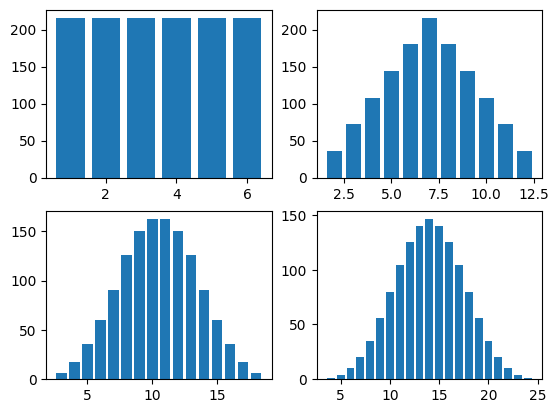

In [ ]:
# A
import numpy as np
import matplotlib.pyplot as plt

dice = np.arange(1,7)
d1, d2 = np.meshgrid(dice, dice)
sums = d1 + d2

print(f"All possible combinations (sample space):\n{sums}")

# B
unique_sums, counts = np.unique(sums, return_counts=True)
print(f"Unique sums: {unique_sums}")
print(f"Frequency: {counts}")

# C
outcomes = sums.size
frequencies = counts / outcomes

for sum, freq in zip(unique_sums, frequencies):
    print(f"The frequency of the sum {sum} is: {freq:.3f}")

print(f"This should be 1: {frequencies.sum()}")

# D
plt.bar(unique_sums, frequencies)

# E
dice = np.arange(1,7)
d1, d2, d3, d4 = np.meshgrid(dice, dice, dice, dice)
one_dice, count_one = np.unique(d1, return_counts=True)
two_dice, count_two = np.unique(d1 + d2, return_counts=True)
three_dice, count_three = np.unique(d1 + d2 + d3, return_counts=True)
four_dice, count_four = np.unique(d1 + d2 + d3 + d4, return_counts=True)
freq_one = count_one / d1.size
freq_two = count_two / (d1+d2).size
freq_three = count_three / (d1+d2+d3).size
freq_four = count_four / (d1+d2+d3+d4).size

plt.subplot(2,2,1)
plt.bar(one_dice, count_one)
plt.subplot(2,2,2)
plt.bar(two_dice, count_two)
plt.subplot(2,2,3)
plt.bar(three_dice, count_three)
plt.subplot(2,2,4)
plt.bar(four_dice, count_four)

plt.show()

--- 
## 3. Monte Carlo simulation (**)

This task has been done in earlier exercise, but now you should do this without any loops. Note that this has enormous performance gain compared to using loops. 

&nbsp; a) Simulate 500000 uniformly distributed points between -1 and 1, $X\sim U(-1,1)$. Now calculate the Euclidean distances between each point and the origin (0,0), $d_i = \sqrt{x_i^2 + y_i^2}$. For $d_i < 1$ plot the point with one color, and for $d_i > 1$ plot the point in another color, $i = \{1,\ldots, 500000\}$.  (**)

&nbsp; b) Calculate the fraction between number of inner points and number of outer points. What do you this will converge to when number of points reaches infinity? (**)


<details>

<summary>Hint</summary>

a) 

Read about numpy random and see if there are some useful methods to use. Also read about 

```
np.linalg.norm()
```

b)

Think in terms of theoretical areas.

</details>

<details>

<summary>Answer</summary>


a) 

<img src="../assets/MC_simulation_500k.png" width = 300>


b) 

0.784724

No answer here, try to prove it theoretically. 


</details>

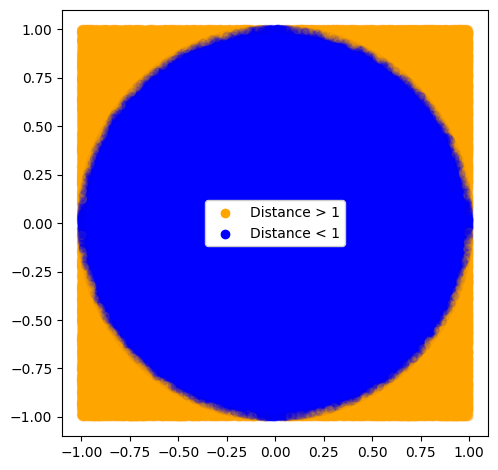

The fraction of inner points vs outer points is: 0.784742


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# A
x = np.random.uniform(-1, 1, 500000)
y = np.random.uniform(-1, 1, 500000)

points = np.column_stack((x, y))
distances = np.linalg.norm(points, axis=1)

colors = np.where(distances > 1, "orange", "blue")
plt.scatter(x, y, color=colors, alpha=0.1)
plt.scatter([],[], color="orange", label="Distance > 1")
plt.scatter([],[], color="blue", label="Distance < 1")
plt.legend(loc="center", framealpha=1.0)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

# B
dist_lower  = np.sum(distances < 1)
dist_higher = np.sum(distances > 1)
fraction = dist_lower / len(distances)
print(f"The fraction of inner points vs outer points is: {fraction}")

---

pr0fez Giang

[LinkedIn][linkedIn_pr0fez]

[GitHub portfolio][github_portfolio]

[linkedIn_pr0fez]: https://www.linkedin.com/in/pr0fezgiang/
[github_portfolio]: https://github.com/pr0fez/Portfolio-pr0fez-Giang

---